In [5]:
conda install tensorflow

2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /home/sahil/miniconda3/envs/ds

  added / updated specs:
    - tensorflow


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    absl-py-2.3.1              |  py313h06a4308_0         434 KB
    astunparse-1.6.3           |             py_0          17 KB
    ca-certificates-2026.7.16  |       h06a4308_0         106 KB
    flatbuffers-24.3.25        |       h6a678d5_0         1.7 MB
    gast-0.7.0                 |     pyhd3eb1b0_0          32 KB
    google-pasta-0.2.0         |     pyhd3eb1b0_0          46 KB
    grpcio-1.78.0              |  py313h7ea928a_1      

In [1]:
import os
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import tensorflow as tf


2026-07-28 23:34:07.094650: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-28 23:34:07.156508: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
dataset_path="../dataset"

In [4]:
classes = sorted(os.listdir(dataset_path))

print(classes)

['basophil', 'erythroblast', 'monocyte', 'myeloblast', 'seg_neutrophil']


In [18]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [7]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 5000 files belonging to 5 classes.
Using 4000 files for training.


In [8]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 5000 files belonging to 5 classes.
Using 1000 files for validation.


In [9]:
class_names = train_ds.class_names

print(class_names)

['basophil', 'erythroblast', 'monocyte', 'myeloblast', 'seg_neutrophil']


In [10]:
for images, labels in train_ds.take(1):

    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


2026-07-28 23:44:04.508336: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-07-28 23:44:21.602694: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


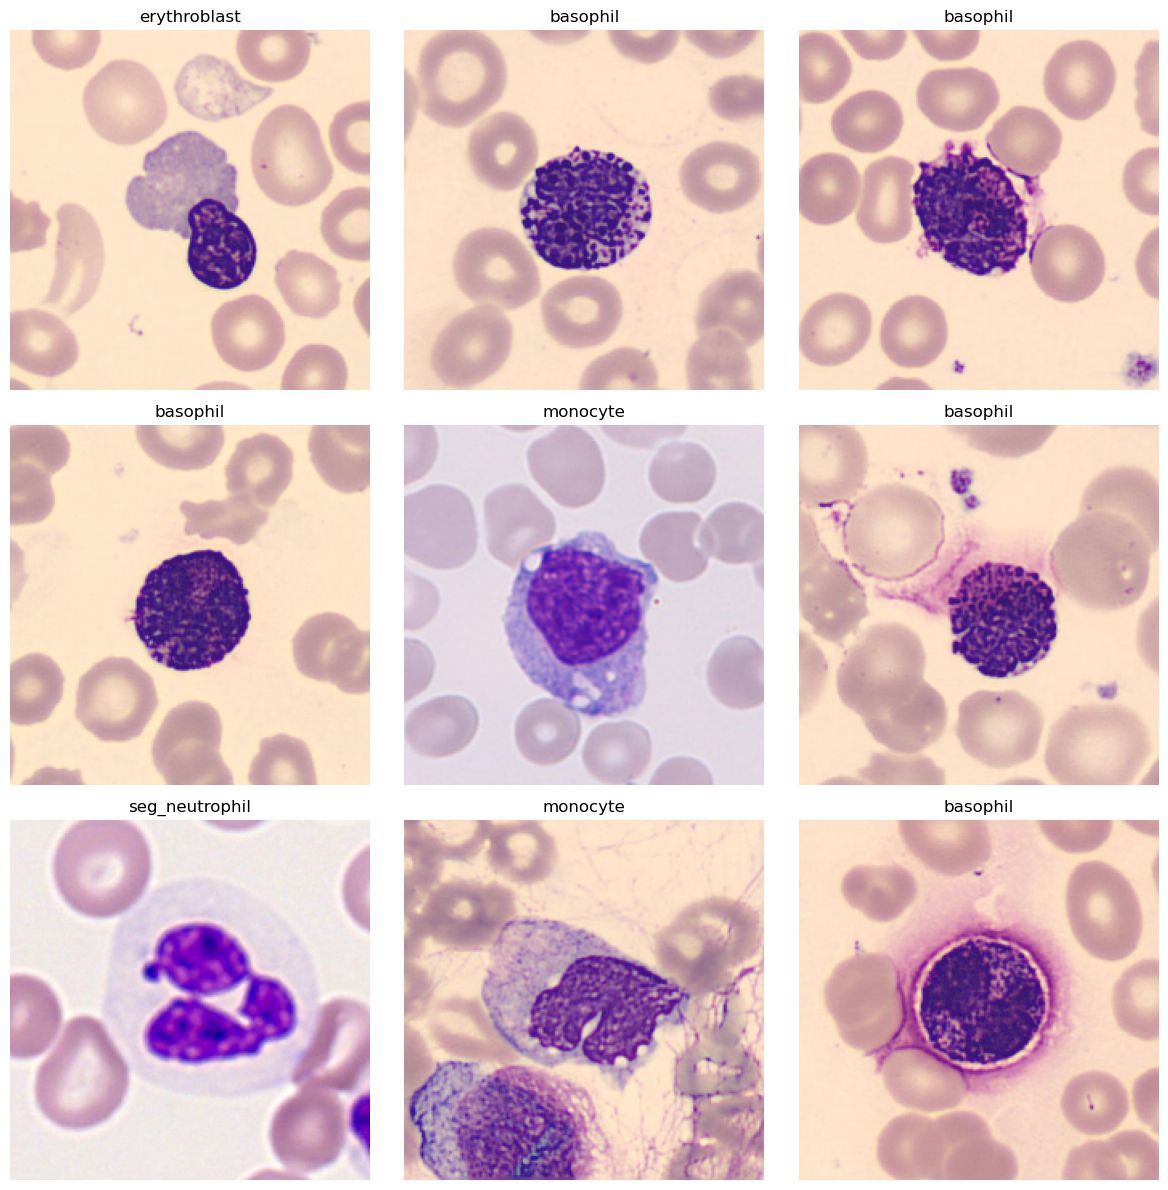

In [11]:
plt.figure(figsize=(12,12))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()

plt.show()

In [12]:
from tensorflow.keras.applications.resnet50 import preprocess_input

In [13]:
def preprocess(image, label):
    image = preprocess_input(image)
    return image, label

In [14]:
train_ds = train_ds.map(preprocess)
val_ds = val_ds.map(preprocess)

In [15]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .cache()
    .shuffle(1000)
    .prefetch(buffer_size=AUTOTUNE)
)

val_ds = (
    val_ds
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

In [16]:
for images, labels in train_ds.take(1):
    print("Image Batch Shape :", images.shape)
    print("Label Batch Shape :", labels.shape)
    print("Image dtype       :", images.dtype)
    print("Label dtype       :", labels.dtype)

Image Batch Shape : (32, 224, 224, 3)
Label Batch Shape : (32,)
Image dtype       : <dtype: 'float32'>
Label dtype       : <dtype: 'int32'>
